# Steganalysis Benchmark — IWT 3-Channel Steganography (Scaled + Deep-Learning Detectors)

**Reorganized into two hardware-aligned blocks:**

- **CPU BLOCK** — image I/O, IWT embedding (Numba-JIT, sequential per-block), PSNR/SSIM,
  chi-square attack. None of this benefits from a GPU; the embedding kernels are
  Numba CPU JIT and the rest is cheap elementwise arithmetic.
- **GPU BLOCK** — RS analysis (now fully vectorized and batched — was the main
  bottleneck), SRM feature extraction (batched), and two CNN-based detectors,
  **Xu-Net** (Xu, Wu, Ni & Shi, 2016) and **Ye-Net** (Ye, Ni & Yi, 2017).

**Recommended hardware: NVIDIA A100 (40GB or 80GB).** This workload is memory-bandwidth
and VRAM bound (large batches of 512×512×3 images through small, shallow CNNs and
fixed high-pass filters), not FLOP bound. An L4's ~300 GB/s bandwidth will bottleneck
the batched conv/RS stages; an H100's extra compute goes largely unused at this model
scale. An A100 is the correct price/performance point. Workstation cards (RTX P6000 /
Quadro RTX 6000) lack the bandwidth and, in the P6000's case, the tensor cores this
pipeline benefits from — this is why the original run felt slow independent of the
RS vectorization fix below.

**The single biggest speed fix in this notebook is not GPU-related at all:** the
original RS analysis was a pure-Python nested loop over 4-pixel groups, calling
numpy functions on tiny arrays tens of thousands of times per image (~11s/image).
It has been rewritten as a fully vectorized, batched tensor operation with zero
Python-level loops over pixel groups. This alone takes RS analysis on 10,000 images
from a ~92-hour projection down to well under a minute.


---
## Two-phase workflow: run the CPU stage once, then resume on GPU as many times as needed

This notebook is split so that the expensive, GPU-irrelevant work — loading
images and running the Numba-JIT IWT embedding — only has to happen **once**.

1. **Phase 1 (CPU instance, run once):** Cells 1–6 (imports → load dataset →
   capacity → embedding → PSNR/SSIM → chi-square), followed by the
   **"Save CPU-Stage Checkpoint"** cell at the end of Phase 1. This writes a
   small checkpoint file (metadata + file paths only, not raw image arrays —
   the images are already on disk) to `CFG["output_dir"]`.
2. **Phase 2 (GPU instance, run whenever you like, as many times as needed):**
   Run Cell 1 only (imports/config — instant, no GPU needed for this part),
   then the **"Resume From Checkpoint"** cell in place of Cells 2–6. This
   reconstructs `stego_bank`, `embed_stats`, `quality_results`, and
   `chi2_results` by reading images back from disk paths rather than
   recomputing anything. Proceed directly from there into the GPU block
   (RS analysis, SRM extraction, Xu-Net, Ye-Net).

You only pay the embedding cost once, regardless of how many times you spin
up a GPU instance to iterate on the RS/SRM/CNN stages afterward.
---

## Cell 1 — Imports, Global Configuration, Hardware Check

In [2]:
import os
import sys
import glob
import random
import warnings
import itertools
from pathlib import Path

warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import chi2 as chi2_dist
from scipy.signal import convolve2d
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix
from tabulate import tabulate
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

sys.path.insert(0, "/teamspace/studios/this_studio")
import IWT_FAST_3CHANNEL as IWT_FAST_MOD

# ─────────────────────────────────────────────────────────────────────────────
# Hardware check
# ─────────────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU detected: {props.name}")
    print(f"  VRAM            : {props.total_memory / 1e9:.1f} GB")
    print(f"  Multiprocessors : {props.multi_processor_count}")
    bandwidth_hint = {
        "A100": "~1.5-2.0 TB/s  — recommended for this workload",
        "H100": "~3.3 TB/s      — more than this workload needs; higher cost/hr",
        "L4":   "~300 GB/s      — will bottleneck batched conv/RS stages",
        "P6000":"~432 GB/s, no tensor cores — not recommended",
        "RTX 6000": "~672 GB/s, has tensor cores but lower VRAM than A100",
    }
    for k, v in bandwidth_hint.items():
        if k in props.name:
            print(f"  Bandwidth note  : {v}")
else:
    print("WARNING: No GPU detected. The GPU BLOCK (RS analysis, SRM extraction, "
          "Xu-Net, Ye-Net) will run on CPU and will be substantially slower, "
          "though the RS vectorization fix still helps enormously even on CPU.")

# ─────────────────────────────────────────────────────────────────────────────
# Experimental configuration
# ─────────────────────────────────────────────────────────────────────────────
CFG = {
    "dataset_dir":   "/teamspace/studios/this_studio/alaska2_raw_color_512/",
    "output_dir":    "/teamspace/studios/this_studio/Next-Gen-Encryption-Steganography/steganalysis_results_v2",
    "dataset_name":  "ALASKA#2 (uncompressed color)",
    "image_res":     "512×512",
    "color_space":   "Native RGB (uncompressed PPM/TIFF)",

    # Experiment scale — scaled to 10,000 images
    "max_images":    5000,
    "payload_rates": [0.1, 0.2, 0.4],
    "n_trials":      10,          # trials for the SRM+LinearSVC classifier
    "n_trials_dl":   3,           # trials for CNN detectors (each trial = full retrain)

    # Classical classifier
    "n_folds":       5,
    "svm_C":         0.01,

    # SRM
    "srm_T":         4,

    # Deep learning training config (shared by Xu-Net / Ye-Net)
    "dl_epochs":     30,
    "dl_batch_size": 32,
    "dl_lr":         1e-3,        # Adamax, as in the original Xu-Net/Ye-Net papers
    "dl_val_split":  0.2,

    # Reproducibility
    "seed":          42,
}

for d in [CFG["output_dir"], os.path.join(CFG["output_dir"], "stego_temp")]:
    os.makedirs(d, exist_ok=True)

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])

print("\nConfiguration:")
for k, v in CFG.items():
    print(f"  {k:<20}: {v}")



Configuration:
  dataset_dir         : /teamspace/studios/this_studio/alaska2_raw_color_512/
  output_dir          : /teamspace/studios/this_studio/Next-Gen-Encryption-Steganography/steganalysis_results_v2
  dataset_name        : ALASKA#2 (uncompressed color)
  image_res           : 512×512
  color_space         : Native RGB (uncompressed PPM/TIFF)
  max_images          : 5000
  payload_rates       : [0.1, 0.2, 0.4]
  n_trials            : 10
  n_trials_dl         : 3
  n_folds             : 5
  svm_C               : 0.01
  srm_T               : 4
  dl_epochs           : 30
  dl_batch_size       : 32
  dl_lr               : 0.001
  dl_val_split        : 0.2
  seed                : 42



# CPU BLOCK

Image loading, IWT embedding (Numba CPU-JIT), PSNR/SSIM, and the chi-square attack.
Nothing here is GPU-acceleratable without rewriting the wavelet lifting kernels as
CUDA kernels — the embedding stage in particular is inherently a per-8×8-block
sequential transform under Numba's CPU backend. It is, however, already fast
relative to RS analysis, so it is not the bottleneck this revision targets.

**Optional CPU-side speedup**, if embedding 10,000 images × 3 payload rates still
feels slow: `IWT.encode_image` is called once per image in a plain `for` loop below.
Since the underlying `@njit` kernels release the GIL during execution, wrapping this
loop in a `concurrent.futures.ThreadPoolExecutor` (rather than a process pool, which
would re-serialize the model/image data) gives close to linear speedup across CPU
cores with no change to `IWT_FAST_3CHANNEL.py` itself. Not applied by default below
to keep the reference path simple and deterministic; swap in a thread pool if needed.


## Cell 2 — Load Dataset

In [4]:
def load_cover_images(directory: str, max_images: int) -> list:
    """
    Loads cover images (TIFF/PPM, already 3-channel color) from `directory`.
    Generalized loader — works for ALASKA#2 uncompressed color releases or any
    similarly formatted 512x512 3-channel image directory.
    """
    paths = sorted(glob.glob(os.path.join(directory, "*.tif")))
    if not paths:
        paths = sorted(glob.glob(os.path.join(directory, "*.ppm")))
    if not paths:
        raise FileNotFoundError(f"No .tif or .ppm files in {directory}")
    paths = paths[:max_images]

    images = []
    for p in tqdm(paths, desc="Loading cover images"):
        bgr = cv2.imread(p, cv2.IMREAD_COLOR)
        if bgr is None:
            continue
        images.append((p, bgr))

    print(f"\nLoaded {len(images)} images")
    print(f"  Shape : {images[0][1].shape}  dtype={images[0][1].dtype}")
    return images


cover_images = load_cover_images(CFG["dataset_dir"], CFG["max_images"])
N_IMAGES = len(cover_images)


Loading cover images:   0%|          | 0/5000 [00:00<?, ?it/s]

Loading cover images: 100%|██████████| 5000/5000 [00:31<00:00, 158.45it/s]


Loaded 5000 images
  Shape : (512, 512, 3)  dtype=uint8


## Cell 3 — Capacity Analysis

In [5]:
def channel_capacity_bytes(img: np.ndarray) -> int:
    iwt_tmp = IWT_FAST_MOD.IWT()
    return iwt_tmp.capacity_bytes(img)


def bpp_to_chars(img: np.ndarray, bpp: float) -> int:
    h, w = img.shape[:2]
    total_bits  = int(h * w * bpp)
    usable_bits = max(0, total_bits - 64)
    return usable_bits // 8


def make_random_ascii(n: int) -> str:
    return ''.join(chr(random.randint(32, 126)) for _ in range(n))


sample_iwt = IWT_FAST_MOD.IWT()
_, sample_img = cover_images[0]
print("=== Capacity Report (representative image) ===")
sample_iwt.capacity_report(sample_img)


=== Capacity Report (representative image) ===
Image size:           512×512 pixels
Blocks per channel:   4096  (64×64)
Bits per channel:     262,144  (32,768 bytes)
Total (3 channels):   786,432 bits  (98,304 bytes)
Usable capacity:      98,288 bytes  (prefix overhead deducted)


In [23]:
# Diagnostic — run this BEFORE any CNN training, on just a few images
test_cover = cover_images[0][1]
test_n_chars = bpp_to_chars(test_cover, 0.1)
print(f"n_chars at 0.1 bpp: {test_n_chars}")

test_message = make_random_ascii(test_n_chars)
print(f"message length: {len(test_message)}, sample: {test_message[:50]!r}")

iwt = IWT_FAST_MOD.IWT()
test_stego = iwt.encode_image(test_cover.copy(), test_message, output_path="/tmp/test_stego.png")

if test_stego is False:
    print("encode_image returned False — capacity check failed")
else:
    diff = np.abs(test_stego.astype(int) - test_cover.astype(int))
    print(f"max pixel diff: {diff.max()}, mean pixel diff: {diff.mean():.6f}, changed pixels: {(diff > 0).sum()}")
    recovered = iwt.decode_image(test_stego)
    print(f"round-trip match: {recovered == test_message}")


n_chars at 0.1 bpp: 3268
message length: 3268, sample: '~ GRU%<yom*}g~]c27;3*^g3%(cC{X~f7JV$4i"h$R4^k^:DbP'
max pixel diff: 3, mean pixel diff: 0.025677, changed pixels: 16407
round-trip match: True


## Cell 4 — Embedding Pipeline (CPU, Numba-JIT IWT)

In [24]:
# def embed_single(cover_bgr: np.ndarray, message: str, out_path: str) -> np.ndarray:
#     iwt = IWT_FAST_MOD.IWT()
#     result = iwt.encode_image(cover_bgr.copy(), message, output_path=out_path)
#     return None if result is False else result


# def verify_extraction(stego_bgr: np.ndarray, original_message: str) -> bool:
#     iwt = IWT_FAST_MOD.IWT()
#     return iwt.decode_image(stego_bgr) == original_message


# stego_bank  = {bpp: [] for bpp in CFG["payload_rates"]}
# embed_stats = {bpp: {"success": 0, "failed": 0, "verify_fail": 0} for bpp in CFG["payload_rates"]}

# for bpp in CFG["payload_rates"]:
#     print(f"\nEmbedding at {bpp} bpp ...")
#     for src_path, cover in tqdm(cover_images, desc=f"bpp={bpp}"):
#         n_chars = bpp_to_chars(cover, bpp)
#         if n_chars < 1:
#             embed_stats[bpp]["failed"] += 1
#             continue
#         message  = make_random_ascii(n_chars)
#         out_path = os.path.join(CFG["output_dir"], "stego_temp", f"{Path(src_path).stem}_{bpp}.png")
#         stego    = embed_single(cover, message, out_path)
#         if stego is None:
#             embed_stats[bpp]["failed"] += 1
#             continue
#         verified = verify_extraction(stego, message)
#         if not verified:
#             embed_stats[bpp]["verify_fail"] += 1
#         stego_bank[bpp].append({
#             "cover": cover, "stego": stego, "message": message,
#             "path": out_path, "cover_path": src_path,
#             "verified": verified, "n_chars": n_chars,
#         })
#         embed_stats[bpp]["success"] += 1

# print("\n=== Embedding Summary ===")
# for bpp in CFG["payload_rates"]:
#     s = embed_stats[bpp]
#     v = sum(1 for r in stego_bank[bpp] if r["verified"])
#     print(f"  bpp={bpp}: {s['success']} embedded | {s['failed']} failed | {v}/{s['success']} verified")


import os
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

N_WORKERS = 20


def _embed_worker(args: tuple) -> dict:
    import IWT_FAST_3CHANNEL as IWT_FAST_MOD

    src_path, cover, bpp, out_path, n_chars, message = args

    iwt = IWT_FAST_MOD.IWT()
    result = iwt.encode_image(cover.copy(), message, output_path=out_path)

    if result is False:
        return {"status": "failed", "src_path": src_path, "bpp": bpp}

    # ── Diagnostic: confirm the returned array actually differs from cover ──
    diff = np.abs(result.astype(int) - cover.astype(int))
    max_diff = int(diff.max())
    if max_diff == 0:
        return {"status": "failed", "src_path": src_path, "bpp": bpp,
                "diagnostic": "returned array identical to cover — embedding lost in worker"}

    verified = iwt.decode_image(result) == message

    return {
        "status": "success",
        "verified": verified,
        "src_path": src_path,
        "bpp": bpp,
        "cover": cover,
        "stego": result,
        "message": message,
        "path": out_path,
        "n_chars": n_chars,
        "max_diff": max_diff,   # sanity-checkable downstream
    }

stego_bank  = {bpp: [] for bpp in CFG["payload_rates"]}
embed_stats = {bpp: {"success": 0, "failed": 0, "verify_fail": 0} for bpp in CFG["payload_rates"]}

for bpp in CFG["payload_rates"]:
    print(f"\nEmbedding at {bpp} bpp (parallel, {N_WORKERS} workers) ...")

    # Build the task list up front, skipping anything that can't fit
    # before spending a worker slot on it.
    tasks = []
    for src_path, cover in cover_images:
        n_chars = bpp_to_chars(cover, bpp)
        if n_chars < 1:
            embed_stats[bpp]["failed"] += 1
            continue
        message  = make_random_ascii(n_chars)
        out_path = os.path.join(CFG["output_dir"], "stego_temp", f"{Path(src_path).stem}_{bpp}.png")
        tasks.append((src_path, cover, bpp, out_path, n_chars, message))

    with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
        futures = [executor.submit(_embed_worker, t) for t in tasks]
        for future in tqdm(as_completed(futures), total=len(futures), desc=f"bpp={bpp}"):
            r = future.result()
            if r["status"] == "failed":
                embed_stats[bpp]["failed"] += 1
                continue
            if not r["verified"]:
                embed_stats[bpp]["verify_fail"] += 1
            stego_bank[bpp].append({
                "cover": r["cover"], "stego": r["stego"], "message": r["message"],
                "path": r["path"], "cover_path": r["src_path"],
                "verified": r["verified"], "n_chars": r["n_chars"],
            })
            embed_stats[bpp]["success"] += 1

print("\n=== Embedding Summary ===")
for bpp in CFG["payload_rates"]:
    s = embed_stats[bpp]
    v = sum(1 for r in stego_bank[bpp] if r["verified"])
    print(f"  bpp={bpp}: {s['success']} embedded | {s['failed']} failed | {v}/{s['success']} verified")



Embedding at 0.1 bpp (parallel, 20 workers) ...


bpp=0.1: 100%|██████████| 5000/5000 [01:16<00:00, 65.08it/s]



Embedding at 0.2 bpp (parallel, 20 workers) ...


bpp=0.2: 100%|██████████| 5000/5000 [01:57<00:00, 42.72it/s]



Embedding at 0.4 bpp (parallel, 20 workers) ...


bpp=0.4: 100%|██████████| 5000/5000 [03:15<00:00, 25.54it/s]



=== Embedding Summary ===
  bpp=0.1: 5000 embedded | 0 failed | 5000/5000 verified
  bpp=0.2: 5000 embedded | 0 failed | 5000/5000 verified
  bpp=0.4: 5000 embedded | 0 failed | 5000/5000 verified


## Cell 5 — Image Quality Metrics (PSNR & SSIM) — CPU

In [ ]:
def compute_psnr(cover: np.ndarray, stego: np.ndarray) -> float:
    mse = np.mean((cover.astype(np.float64) - stego.astype(np.float64)) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)


def compute_ssim(cover: np.ndarray, stego: np.ndarray) -> float:
    c1, c2 = (0.01 * 255) ** 2, (0.03 * 255) ** 2
    ssim_vals = []
    for ch in range(cover.shape[2]):
        a, b = cover[:, :, ch].astype(np.float64), stego[:, :, ch].astype(np.float64)
        mu_a, mu_b = a.mean(), b.mean()
        sig_a, sig_b = a.std() ** 2, b.std() ** 2
        sig_ab = np.mean((a - mu_a) * (b - mu_b))
        num = (2 * mu_a * mu_b + c1) * (2 * sig_ab + c2)
        den = (mu_a**2 + mu_b**2 + c1) * (sig_a + sig_b + c2)
        ssim_vals.append(num / den)
    return float(np.mean(ssim_vals))


quality_results = {}
for bpp in CFG["payload_rates"]:
    psnrs = [compute_psnr(r["cover"], r["stego"]) for r in stego_bank[bpp]]
    ssims = [compute_ssim(r["cover"], r["stego"]) for r in stego_bank[bpp]]
    quality_results[bpp] = {
        "psnr_mean": np.mean(psnrs), "psnr_std": np.std(psnrs),
        "ssim_mean": np.mean(ssims), "ssim_std": np.std(ssims),
    }

print(tabulate(
    [[bpp, f"{r['psnr_mean']:.2f} ± {r['psnr_std']:.2f}",
      f"{r['ssim_mean']:.6f} ± {r['ssim_std']:.6f}"]
     for bpp, r in quality_results.items()],
    headers=["Payload (bpp)", "PSNR (dB)", "SSIM"], tablefmt="grid"
))


+-----------------+--------------+---------------------+
|   Payload (bpp) | PSNR (dB)    | SSIM                |
+=================+==============+=====================+
|             0.1 | 57.32 ± 9.34 | 0.999021 ± 0.007676 |
+-----------------+--------------+---------------------+
|             0.2 | 53.83 ± 9.42 | 0.998254 ± 0.010519 |
+-----------------+--------------+---------------------+
|             0.4 | 50.24 ± 9.40 | 0.996954 ± 0.014946 |
+-----------------+--------------+---------------------+


## Cell 6 — Chi-Square Attack — CPU

In [10]:
def chi_square_attack_per_channel(img: np.ndarray) -> dict:
    """
    Manual chi-square (not scipy.stats.chisquare — see note): observed is the
    count at each even byte value, expected is the pair-average of (even, odd)
    counts. These sums are not required to match, which scipy's chisquare
    silently assumes. Computed here directly: stat = sum((O-E)^2/E),
    p = chi2.sf(stat, dof).
    """
    results = {}
    for ch_idx, ch_name in enumerate(["B", "G", "R"]):
        channel = img[:, :, ch_idx].ravel().astype(np.uint8)
        hist = np.bincount(channel, minlength=256).astype(float)
        observed, expected = [], []
        for k in range(0, 256, 2):
            pair_sum = hist[k] + hist[k + 1]
            if pair_sum > 0:
                observed.append(hist[k]); expected.append(pair_sum / 2.0)
        obs, exp = np.array(observed), np.array(expected)
        mask = exp > 0
        obs, exp = obs[mask], exp[mask]
        stat = float(np.sum((obs - exp) ** 2 / exp))
        dof  = len(obs) - 1
        p    = float(chi2_dist.sf(stat, dof)) if dof > 0 else 1.0
        results[ch_name] = (stat, p)
    results["mean_stat"] = np.mean([v[0] for v in results.values() if isinstance(v, tuple)])
    results["min_p"]     = min(v[1] for v in results.values() if isinstance(v, tuple))
    return results


chi2_results = {}
for bpp in CFG["payload_rates"]:
    cover_stats = [chi_square_attack_per_channel(r["cover"]) for r in tqdm(stego_bank[bpp], desc=f"Chi² cover bpp={bpp}")]
    stego_stats = [chi_square_attack_per_channel(r["stego"]) for r in tqdm(stego_bank[bpp], desc=f"Chi² stego bpp={bpp}")]
    chi2_results[bpp] = {
        "cover_p_mean": np.mean([s["min_p"] for s in cover_stats]),
        "stego_p_mean": np.mean([s["min_p"] for s in stego_stats]),
    }

print(tabulate(
    [[bpp, f"{r['cover_p_mean']:.4f}", f"{r['stego_p_mean']:.4f}"]
     for bpp, r in chi2_results.items()],
    headers=["Payload (bpp)", "Cover p (mean)", "Stego p (mean)"], tablefmt="grid"
))


Chi² stego bpp=0.4: 100%|██████████| 5000/5000 [00:11<00:00, 452.70it/s]

+-----------------+------------------+------------------+
|   Payload (bpp) |   Cover p (mean) |   Stego p (mean) |
+=================+==================+==================+
|             0.1 |           0.0272 |           0.0276 |
+-----------------+------------------+------------------+
|             0.2 |           0.0272 |           0.0292 |
+-----------------+------------------+------------------+
|             0.4 |           0.0272 |           0.03   |
+-----------------+------------------+------------------+


## Cell 6.5 — Save CPU-Stage Checkpoint (run once, at the end of Phase 1)

In [11]:
import pickle

CHECKPOINT_PATH = os.path.join(CFG["output_dir"], "cpu_stage_checkpoint.pkl")


def _strip_arrays(records: list) -> list:
    """
    Keeps only file paths and metadata, not the raw image arrays. Cover
    images already exist as files in CFG["dataset_dir"]; stego images were
    already written to disk during embedding (out_path). Storing paths
    instead of arrays keeps the checkpoint file small (KBs, not GBs) and
    avoids duplicating tens of thousands of images into a pickle blob.
    """
    return [{
        "cover_path": r["cover_path"],
        "stego_path": r["path"],
        "message":    r["message"],
        "verified":   r["verified"],
        "n_chars":    r["n_chars"],
    } for r in records]


checkpoint = {
    "cfg_snapshot":    {k: CFG[k] for k in ["dataset_dir", "max_images", "payload_rates"]},
    "stego_bank_meta": {bpp: _strip_arrays(stego_bank[bpp]) for bpp in CFG["payload_rates"]},
    "embed_stats":     embed_stats,
    "quality_results": quality_results,
    "chi2_results":    chi2_results,
}

with open(CHECKPOINT_PATH, "wb") as f:
    pickle.dump(checkpoint, f)

n_pairs = sum(len(v) for v in checkpoint["stego_bank_meta"].values())
print(f"Checkpoint saved to {CHECKPOINT_PATH}")
print(f"  Contains metadata for {n_pairs} embedded (cover, stego) pairs across "
      f"{len(checkpoint['stego_bank_meta'])} payload rates.")
print("\nYou can now switch to a GPU-enabled runtime. Run Cell 1 (imports/config), "
      "then the 'Resume From Checkpoint' cell below in place of Cells 2-6 — "
      "no need to re-run image loading, embedding, PSNR/SSIM, or chi-square.")


Checkpoint saved to /teamspace/studios/this_studio/Next-Gen-Encryption-Steganography/steganalysis_results_v2/cpu_stage_checkpoint.pkl
  Contains metadata for 15000 embedded (cover, stego) pairs across 3 payload rates.

You can now switch to a GPU-enabled runtime. Run Cell 1 (imports/config), then the 'Resume From Checkpoint' cell below in place of Cells 2-6 — no need to re-run image loading, embedding, PSNR/SSIM, or chi-square.


# GPU BLOCK

RS analysis (fully vectorized + batched — the main fix), SRM feature extraction
(batched), and two CNN-based detectors (Xu-Net, Ye-Net). All tensor operations
below are batched across images so the GPU processes many images per kernel
launch rather than one Python-level call per image, which is what made the
original RS analysis (and would make a naively-ported CNN pipeline) slow.


## Resume From Checkpoint (Phase 2 — run this instead of Cells 2–6)

Run this cell right after Cell 1 (imports/config) whenever starting a fresh
session on a GPU-enabled instance. It reconstructs `stego_bank`,
`embed_stats`, `quality_results`, and `chi2_results` by reading images back
from the file paths saved in the checkpoint, rather than recomputing the
CPU-block embedding, quality metrics, or chi-square attack.

If you are continuing in the *same* kernel session where Phase 1 just ran,
skip this cell — `stego_bank` etc. are already in memory.


In [3]:
import pickle
import cv2

CHECKPOINT_PATH = os.path.join(CFG["output_dir"], "cpu_stage_checkpoint.pkl")


def resume_from_checkpoint(path: str = CHECKPOINT_PATH) -> dict:
    """
    Reconstructs stego_bank, embed_stats, quality_results, and chi2_results
    from a checkpoint saved by the "Save CPU-Stage Checkpoint" cell, without
    re-running embedding, PSNR/SSIM, or chi-square. Images are re-read from
    disk (cover from the original dataset directory, stego from the paths
    written during embedding) rather than being pickled directly, keeping
    the checkpoint file small regardless of dataset size.

    Cell 1 (imports/config) must be run first, since it defines CFG and DEVICE.
    """
    with open(path, "rb") as f:
        checkpoint = pickle.load(f)

    saved_cfg = checkpoint["cfg_snapshot"]
    for key, saved_val in saved_cfg.items():
        if CFG.get(key) != saved_val:
            print(f"WARNING: CFG['{key}'] = {CFG.get(key)} differs from the checkpoint\'s "
                  f"saved value {saved_val}. Proceeding with the checkpoint\'s data as-is; "
                  f"update CFG to match if this is unexpected.")

    stego_bank_restored = {bpp: [] for bpp in saved_cfg["payload_rates"]}
    total = sum(len(v) for v in checkpoint["stego_bank_meta"].values())
    n_missing = 0

    with tqdm(total=total, desc="Reloading images from disk") as pbar:
        for bpp, records in checkpoint["stego_bank_meta"].items():
            bpp = float(bpp)
            for r in records:
                cover = cv2.imread(r["cover_path"], cv2.IMREAD_COLOR)
                stego = cv2.imread(r["stego_path"], cv2.IMREAD_COLOR)
                if cover is None or stego is None:
                    n_missing += 1
                    pbar.update(1)
                    continue
                stego_bank_restored[bpp].append({
                    "cover": cover, "stego": stego, "message": r["message"],
                    "path": r["stego_path"], "cover_path": r["cover_path"],
                    "verified": r["verified"], "n_chars": r["n_chars"],
                })
                pbar.update(1)

    if n_missing:
        print(f"WARNING: {n_missing} of {total} image pairs could not be reloaded "
              f"(missing files) and were skipped.")

    return {
        "stego_bank":      stego_bank_restored,
        "embed_stats":     checkpoint["embed_stats"],
        "quality_results": checkpoint["quality_results"],
        "chi2_results":    checkpoint["chi2_results"],
    }


_resumed = resume_from_checkpoint()
stego_bank      = _resumed["stego_bank"]
embed_stats     = _resumed["embed_stats"]
quality_results = _resumed["quality_results"]
chi2_results    = _resumed["chi2_results"]

N_IMAGES = len({r["cover_path"] for records in stego_bank.values() for r in records})
n_pairs  = sum(len(v) for v in stego_bank.values())

print(f"\nResumed from checkpoint: {n_pairs} stego pairs across "
      f"{len(stego_bank)} payload rates ({N_IMAGES} unique cover images).")
print("Ready to proceed directly into the GPU block (RS analysis, SRM extraction, "
      "Xu-Net, Ye-Net) below.")


Reloading images from disk:   0%|          | 0/15000 [00:00<?, ?it/s]

Reloading images from disk:  44%|████▎     | 6535/15000 [02:09<16:16:42,  6.92s/it]

: 

## Cell 7 — RS Analysis (fully vectorized, GPU-batched)

**This replaces the previous per-group Python loop entirely.** The original
implementation iterated over every 2-row × 4-column pixel group with nested
Python `for` loops, calling `flip_fn` and `discriminant` (each doing further
numpy work) on 4-element arrays tens of thousands of times per image — this is
why it took ~11 seconds per image.

The RS algorithm is embarrassingly parallel across groups: every group's R/S/
R_neg/S_neg classification is independent of every other group and every other
image. The version below reshapes each channel into non-overlapping groups via
a single `reshape` (no loop), computes the flipped/negative-flipped
discriminants for *all* groups of *all* images in one batched tensor operation,
and reduces to R/S counts with boolean sums. There is no per-group or per-image
Python-level loop anywhere in this cell.


In [14]:
def rs_analysis_batch_gpu(imgs_np: np.ndarray) -> np.ndarray:
    """
    Fully vectorized RS steganalysis (Fridrich, Goljan & Du, 2001), batched
    across N images and all 3 channels simultaneously on GPU.

    Parameters
    ----------
    imgs_np : np.ndarray, shape (N, H, W, 3), dtype uint8

    Returns
    -------
    np.ndarray, shape (N,) — estimated payload fraction per image
               (averaged across the 3 channels, matching the original
               per-channel-then-mean behaviour).

    Method
    ------
    Groups are non-overlapping 1×4 pixel runs taken from every other row,
    matching the original algorithm's traversal (i in range(0,H-1,2),
    j in range(0,W-4+1,4)). This is achieved with a single reshape:
        row_subset = channel[:, 0:H:2, :]                # (N, H/2, W)
        groups     = row_subset.reshape(N, H/2, W//4, 4)  # (N, H/2, W//4, 4)
    No Python-level loop over groups or images is used anywhere below.
    """
    N, H, W, C = imgs_np.shape
    imgs = torch.from_numpy(imgs_np).to(DEVICE, dtype=torch.float32)  # (N,H,W,3)

    mask     = torch.tensor([0., 1., 0., 1.], device=DEVICE).view(1, 1, 1, 4)
    mask_neg = 1.0 - mask

    channel_estimates = []

    for ch in range(3):
        channel = imgs[:, :, :, ch]                      # (N, H, W)
        row_sub = channel[:, 0:H - (H % 2):2, :]          # (N, H/2, W) — even rows only
        h2      = row_sub.shape[1]
        w4      = (W // 4) * 4
        groups  = row_sub[:, :, :w4].reshape(N, h2, W // 4, 4)   # (N, h2, W//4, 4)

        def discriminant(g: torch.Tensor) -> torch.Tensor:
            # Sum of |differences| between adjacent elements in each group of 4
            return torch.sum(torch.abs(g[..., 1:] - g[..., :-1]), dim=-1)  # (N, h2, W//4)

        def flip(g: torch.Tensor, m: torch.Tensor) -> torch.Tensor:
            parity = torch.remainder(g, 2.0)
            delta  = torch.where(parity == 0, torch.ones_like(g), -torch.ones_like(g))
            return g + delta * m

        d0    = discriminant(groups)
        d_f   = discriminant(flip(groups, mask))
        d_fn  = discriminant(flip(groups, mask_neg))

        # R/S counts, reduced over all groups per image -> (N,)
        R     = torch.sum(d_f  > d0, dim=(1, 2)).float()
        S     = torch.sum(d_f  < d0, dim=(1, 2)).float()
        R_neg = torch.sum(d_fn > d0, dim=(1, 2)).float()
        S_neg = torch.sum(d_fn < d0, dim=(1, 2)).float()

        denom = (R - S + R_neg - S_neg)
        est   = torch.where(
            denom != 0,
            (R - R_neg) / denom,
            torch.zeros_like(denom),
        )
        est = torch.clamp(est, 0.0, 1.0)
        channel_estimates.append(est)

    per_channel = torch.stack(channel_estimates, dim=0)   # (3, N)
    return per_channel.mean(dim=0).cpu().numpy()          # (N,)


# ── Run RS analysis for all cover/stego pairs at each payload rate ───────────
# Batched across images in chunks to bound peak VRAM usage.
RS_BATCH_SIZE = 256

rs_results = {}

for bpp in CFG["payload_rates"]:
    records = stego_bank[bpp]
    n = len(records)

    cover_ests, stego_ests = [], []
    for start in tqdm(range(0, n, RS_BATCH_SIZE), desc=f"RS bpp={bpp} (GPU batched)"):
        end = min(start + RS_BATCH_SIZE, n)
        chunk = records[start:end]
        cover_batch = np.stack([r["cover"] for r in chunk], axis=0)
        stego_batch = np.stack([r["stego"] for r in chunk], axis=0)
        cover_ests.extend(rs_analysis_batch_gpu(cover_batch).tolist())
        stego_ests.extend(rs_analysis_batch_gpu(stego_batch).tolist())

    rs_results[bpp] = {
        "cover_mean": np.mean(cover_ests), "cover_std": np.std(cover_ests),
        "stego_mean": np.mean(stego_ests), "stego_std": np.std(stego_ests),
    }

print(tabulate(
    [[bpp, f"{r['cover_mean']:.4f} ± {r['cover_std']:.4f}",
      f"{r['stego_mean']:.4f} ± {r['stego_std']:.4f}", f"{bpp/3:.4f}"]
     for bpp, r in rs_results.items()],
    headers=["Payload (bpp)", "RS Cover Est.", "RS Stego Est.", "True Rate (bpp/ch)"],
    tablefmt="grid"
))
print("\nNote: this cell should complete in seconds, not hours, at N=10,000.")


RS bpp=0.4 (GPU batched): 100%|██████████| 20/20 [00:11<00:00,  1.75it/s]

+-----------------+-----------------+-----------------+----------------------+
|   Payload (bpp) | RS Cover Est.   | RS Stego Est.   |   True Rate (bpp/ch) |
+=================+=================+=================+======================+
|             0.1 | 0.0064 ± 0.0167 | 0.0064 ± 0.0170 |               0.0333 |
+-----------------+-----------------+-----------------+----------------------+
|             0.2 | 0.0064 ± 0.0167 | 0.0063 ± 0.0158 |               0.0667 |
+-----------------+-----------------+-----------------+----------------------+
|             0.4 | 0.0064 ± 0.0167 | 0.0062 ± 0.0153 |               0.1333 |
+-----------------+-----------------+-----------------+----------------------+

Note: this cell should complete in seconds, not hours, at N=10,000.


## Cell 8 — SRM Feature Extraction (GPU-batched)

In [29]:
SRM_KERNELS = {
    "h1_horiz":   np.array([[-1,  1]],             dtype=np.float64) / 1.0,
    "h1_vert":    np.array([[-1], [1]],             dtype=np.float64) / 1.0,
    "h2_horiz":   np.array([[1, -2,  1]],           dtype=np.float64) / 2.0,
    "h2_vert":    np.array([[1], [-2], [1]],         dtype=np.float64) / 2.0,
    "h2_diag":    np.array([[1, 0, 0], [0, -2, 0], [0, 0, 1]], dtype=np.float64) / 2.0,
    "h2_adiag":   np.array([[0, 0, 1], [0, -2, 0], [1, 0, 0]], dtype=np.float64) / 2.0,
    "h3_horiz":   np.array([[-1, 3, -3, 1]],        dtype=np.float64) / 3.0,
    "h3_vert":    np.array([[-1], [3], [-3], [1]],   dtype=np.float64) / 3.0,
    "laplacian4": np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], dtype=np.float64) / 4.0,
    "laplacian8": np.array([[-1,-1,-1],[-1, 8,-1],[-1,-1,-1]],    dtype=np.float64) / 8.0,
    "edge5h":     np.array([[-1, 2, -2, 2, -1]],    dtype=np.float64) / 4.0,
    "edge5v":     np.array([[-1], [2], [-2], [2], [-1]], dtype=np.float64) / 4.0,
}
KERNEL_NAMES = list(SRM_KERNELS.keys())
_KERNEL_TENSORS = {
    name: torch.tensor(k, dtype=torch.float32, device=DEVICE).unsqueeze(0).unsqueeze(0)
    for name, k in SRM_KERNELS.items()
}


def _pad_symmetric(x, pad):
    left, right, top, bottom = pad
    if left:   x = torch.cat([x[:, :, :, :left].flip(-1), x], dim=-1)
    if right:  x = torch.cat([x, x[:, :, :, -right:].flip(-1)], dim=-1)
    if top:    x = torch.cat([x[:, :, :top, :].flip(-2), x], dim=-2)
    if bottom: x = torch.cat([x, x[:, :, -bottom:, :].flip(-2)], dim=-2)
    return x


def _conv_same(x, kernel):
    kh, kw = kernel.shape[-2], kernel.shape[-1]
    pt, pb = (kh - 1) // 2, kh - 1 - (kh - 1) // 2
    pl, pr = (kw - 1) // 2, kw - 1 - (kw - 1) // 2
    return F.conv2d(_pad_symmetric(x, (pl, pr, pt, pb)), kernel)


def _batched_bincount_1d(values, num_bins):
    B, L = values.shape
    offsets = (torch.arange(B, device=values.device) * num_bins).unsqueeze(1)
    counts = torch.bincount((values + offsets).reshape(-1), minlength=B * num_bins)
    return counts.reshape(B, num_bins).to(torch.float32)


def _batched_bincount_2d(left, right, num_bins):
    B, L = left.shape
    idx = left * num_bins + right
    offsets = (torch.arange(B, device=left.device) * num_bins * num_bins).unsqueeze(1)
    counts = torch.bincount((idx + offsets).reshape(-1), minlength=B * num_bins * num_bins)
    return counts.reshape(B, num_bins, num_bins).to(torch.float32)


_bins = 2 * CFG["srm_T"] + 1
_triu_i, _triu_j = torch.triu_indices(_bins, _bins, device=DEVICE)


def extract_srm_features_batch(imgs_np: np.ndarray, T: int = CFG["srm_T"]) -> np.ndarray:
    imgs = torch.from_numpy(imgs_np).to(DEVICE, dtype=torch.float32)
    N, H, W, C = imgs.shape
    imgs = imgs.permute(0, 3, 1, 2).contiguous()
    bins = 2 * T + 1
    all_feats = []
    with torch.no_grad():
        for ch in range(3):
            x = imgs[:, ch:ch+1, :, :]
            for name in KERNEL_NAMES:
                residual = _conv_same(x, _KERNEL_TENSORS[name])
                residual = torch.clamp(torch.round(residual), -T, T).to(torch.int64) + T
                residual = residual.squeeze(1)
                flat = residual.reshape(N, -1)
                hist = _batched_bincount_1d(flat, bins)
                hist = hist / (hist.sum(dim=1, keepdim=True) + 1e-12)
                left  = residual[:, :, :-1].reshape(N, -1)
                right = residual[:, :, 1:].reshape(N, -1)
                co = _batched_bincount_2d(left, right, bins)
                co = co / (co.sum(dim=(1, 2), keepdim=True) + 1e-12)
                co_sym  = (co + co.transpose(1, 2)) / 2.0
                co_triu = co_sym[:, _triu_i, _triu_j]
                all_feats.append(hist)
                all_feats.append(co_triu)
    return torch.cat(all_feats, dim=1).cpu().numpy().astype(np.float32)


print("Extracting SRM features for all cover/stego pairs (CUDA batched) ...")
_feat_dim = 3 * len(KERNEL_NAMES) * (_bins + _triu_i.numel())
print(f"Feature vector length: {_feat_dim}")

SRM_BATCH_SIZE = 32
srm_cache = {}

for bpp in CFG["payload_rates"]:
    records = stego_bank[bpp]
    n = len(records)
    for start in tqdm(range(0, n, SRM_BATCH_SIZE), desc=f"SRM bpp={bpp}"):
        end = min(start + SRM_BATCH_SIZE, n)
        chunk = records[start:end]
        cover_batch = np.stack([r["cover"] for r in chunk], axis=0)
        stego_batch = np.stack([r["stego"] for r in chunk], axis=0)
        cover_feats = extract_srm_features_batch(cover_batch)
        stego_feats = extract_srm_features_batch(stego_batch)
        for i, idx in enumerate(range(start, end)):
            srm_cache[(bpp, idx, "cover")] = cover_feats[i]
            srm_cache[(bpp, idx, "stego")] = stego_feats[i]

print("SRM feature extraction complete.")


Extracting SRM features for all cover/stego pairs (CUDA batched) ...
Feature vector length: 1944


SRM bpp=0.1:   0%|          | 0/157 [00:00<?, ?it/s]

SRM bpp=0.4: 100%|██████████| 157/157 [00:32<00:00,  4.87it/s]

SRM feature extraction complete.


## Cell 9 — Classical Detector: LinearSVC on SRM Features

In [16]:
class LinearSVMTorch(nn.Module):
    """GPU linear SVM: single linear layer trained with hinge loss."""
    def __init__(self, n_features: int):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x).squeeze(1)


def train_linear_svm_gpu(X_train, y_train, C=CFG["svm_C"], epochs=200, lr=0.05):
    """
    Trains a linear SVM on GPU via hinge loss + L2 regularization, matching
    LinearSVC's objective. Full-batch training — at 1944 features and a few
    thousand samples this comfortably fits in memory and converges in
    well under a second on an H100, versus ~10s/fold for liblinear on CPU.
    """
    model = LinearSVMTorch(X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    y_pm1 = torch.where(y_train == 1, 1.0, -1.0)

    for _ in range(epochs):
        optimizer.zero_grad()
        scores = model(X_train)
        hinge = torch.clamp(1 - y_pm1 * scores, min=0).mean()
        reg = 0.5 * torch.sum(model.linear.weight ** 2)
        loss = reg + C * hinge * X_train.shape[0]
        loss.backward()
        optimizer.step()

    return model


def build_dataset(bpp: float) -> tuple:
    X, y = [], []
    for idx in range(len(stego_bank[bpp])):
        X.append(srm_cache[(bpp, idx, "cover")]); y.append(0)
        X.append(srm_cache[(bpp, idx, "stego")]); y.append(1)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


def run_single_trial_svm_gpu(X_np, y_np, seed, C=CFG["svm_C"], n_folds=CFG["n_folds"]) -> dict:
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    fold_pe, fold_acc = [], []
    all_y_true, all_y_score = [], []

    for train_idx, test_idx in skf.split(X_np, y_np):
        X_tr_np, X_te_np = X_np[train_idx], X_np[test_idx]
        y_tr_np, y_te_np = y_np[train_idx], y_np[test_idx]

        # Standardization computed on GPU, fit on train fold only
        X_tr = torch.from_numpy(X_tr_np).to(DEVICE, dtype=torch.float32)
        X_te = torch.from_numpy(X_te_np).to(DEVICE, dtype=torch.float32)
        mean = X_tr.mean(dim=0, keepdim=True)
        std  = X_tr.std(dim=0, keepdim=True) + 1e-8
        X_tr = (X_tr - mean) / std
        X_te = (X_te - mean) / std
        y_tr = torch.from_numpy(y_tr_np).to(DEVICE, dtype=torch.float32)

        model = train_linear_svm_gpu(X_tr, y_tr, C=C)

        model.eval()
        with torch.no_grad():
            scores_te = model(X_te)
        y_score = scores_te.cpu().numpy()
        y_pred  = (y_score > 0).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_te_np, y_pred).ravel()
        pe = 0.5 * (fp / (fp + tn + 1e-12) + fn / (fn + tp + 1e-12))
        fold_pe.append(pe)
        fold_acc.append(accuracy_score(y_te_np, y_pred))
        all_y_true.extend(y_te_np)
        all_y_score.extend(y_score)

    fpr, tpr, _ = roc_curve(all_y_true, all_y_score)
    return {"pe_mean": np.mean(fold_pe), "pe_std": np.std(fold_pe),
            "acc_mean": np.mean(fold_acc), "acc_std": np.std(fold_acc),
            "auc": auc(fpr, tpr), "fpr": fpr, "tpr": tpr}


svm_trial_results = {bpp: [] for bpp in CFG["payload_rates"]}
for bpp in CFG["payload_rates"]:
    X, y = build_dataset(bpp)
    print(f"SRM+SVM (GPU)  bpp={bpp}  |  {X.shape[0]} samples  |  {X.shape[1]} features")
    for trial in tqdm(range(CFG["n_trials"]), desc=f"SVM trials bpp={bpp}"):
        svm_trial_results[bpp].append(run_single_trial_svm_gpu(X, y, seed=CFG["seed"] + trial * 1000))

svm_aggregated = {}
for bpp in CFG["payload_rates"]:
    trials = svm_trial_results[bpp]
    svm_aggregated[bpp] = {
        "pe_mean":  np.mean([t["pe_mean"]  for t in trials]), "pe_std":  np.std([t["pe_mean"]  for t in trials]),
        "auc_mean": np.mean([t["auc"]      for t in trials]), "auc_std": np.std([t["auc"]      for t in trials]),
    }

print(tabulate(
    [[bpp, f"{r['pe_mean']:.4f}±{r['pe_std']:.4f}", f"{r['auc_mean']:.4f}±{r['auc_std']:.4f}"]
     for bpp, r in svm_aggregated.items()],
    headers=["Payload (bpp)", "PE", "AUC"], tablefmt="grid"
))


SRM+SVM (GPU)  bpp=0.1  |  10000 samples  |  1944 features


SVM trials bpp=0.1: 100%|██████████| 10/10 [00:21<00:00,  2.11s/it]


SRM+SVM (GPU)  bpp=0.2  |  10000 samples  |  1944 features


SVM trials bpp=0.2: 100%|██████████| 10/10 [00:18<00:00,  1.89s/it]


SRM+SVM (GPU)  bpp=0.4  |  10000 samples  |  1944 features


SVM trials bpp=0.4: 100%|██████████| 10/10 [00:20<00:00,  2.01s/it]

+-----------------+---------------+---------------+
|   Payload (bpp) | PE            | AUC           |
+=================+===============+===============+
|             0.1 | 0.4800±0.0080 | 0.5286±0.0103 |
+-----------------+---------------+---------------+
|             0.2 | 0.4235±0.0048 | 0.6091±0.0063 |
+-----------------+---------------+---------------+
|             0.4 | 0.3354±0.0074 | 0.7257±0.0090 |
+-----------------+---------------+---------------+


## Cell 10 — Deep Learning Detector: Xu-Net

Reimplementation of Xu, Wu, Ni & Shi (2016), *"Structural Design of Convolutional
Neural Networks for Steganalysis."* Key structural elements preserved: a fixed
(non-trainable) high-pass preprocessing filter, absolute-value activation in the
first block to fold the residual's sign symmetry, TanH activations in the early
layers (bounded, unlike ReLU, which the original paper found destabilizes early
training on the small-magnitude residuals), a shift to ReLU in deeper layers, and
global average pooling before the final classifier — no large fully-connected
layers, which the original paper identifies as prone to overfitting on
steganalysis feature maps.


In [17]:
# class AbsActivation(nn.Module):
#     def forward(self, x):
#         return torch.abs(x)


# class XuNet(nn.Module):
#     """
#     Xu-Net (Xu et al., 2016). Input: (B, 3, H, W) stego/cover patches.
#     Fixed high-pass filter -> 5 conv groups -> global average pool -> FC(2).
#     """
#     def __init__(self, in_channels: int = 3):
#         super().__init__()

#         # Fixed high-pass preprocessing filter (KV kernel), one per input channel,
#         # not updated during training (requires_grad=False).
#         kv_kernel = torch.tensor([
#             [-1,  2, -2,  2, -1],
#             [ 2, -6,  8, -6,  2],
#             [-2,  8, -12, 8, -2],
#             [ 2, -6,  8, -6,  2],
#             [-1,  2, -2,  2, -1],
#         ], dtype=torch.float32) / 12.0
#         self.register_buffer("kv_kernel", kv_kernel.view(1, 1, 5, 5).repeat(in_channels, 1, 1, 1))
#         self.hpf_groups = in_channels

#         self.group1 = nn.Sequential(
#             nn.Conv2d(in_channels, 8, kernel_size=5, padding=2, bias=False),
#             nn.BatchNorm2d(8), AbsActivation(), nn.Tanh(),
#             nn.AvgPool2d(5, stride=2, padding=2),
#         )
#         self.group2 = nn.Sequential(
#             nn.Conv2d(8, 16, kernel_size=5, padding=2, bias=False),
#             nn.BatchNorm2d(16), nn.Tanh(),
#             nn.AvgPool2d(5, stride=2, padding=2),
#         )
#         self.group3 = nn.Sequential(
#             nn.Conv2d(16, 32, kernel_size=1, bias=False),
#             nn.BatchNorm2d(32), nn.ReLU(True),
#             nn.AvgPool2d(5, stride=2, padding=2),
#         )
#         self.group4 = nn.Sequential(
#             nn.Conv2d(32, 64, kernel_size=1, bias=False),
#             nn.BatchNorm2d(64), nn.ReLU(True),
#             nn.AvgPool2d(5, stride=2, padding=2),
#         )
#         self.group5 = nn.Sequential(
#             nn.Conv2d(64, 128, kernel_size=1, bias=False),
#             nn.BatchNorm2d(128), nn.ReLU(True),
#         )
#         self.global_pool = nn.AdaptiveAvgPool2d(1)
#         self.fc = nn.Linear(128, 2)

#     def forward(self, x):
#         x = F.conv2d(x, self.kv_kernel, padding=2, groups=self.hpf_groups)
#         x = self.group1(x); x = self.group2(x); x = self.group3(x)
#         x = self.group4(x); x = self.group5(x)
#         x = self.global_pool(x).flatten(1)
#         return self.fc(x)


## Cell 11 — Deep Learning Detector: Ye-Net

Reimplementation of Ye, Ni & Yi (2017), *"Deep Learning Hierarchical
Representations for Image Steganalysis."* Key structural elements preserved:
30 fixed SRM high-pass filters (rather than Xu-Net's single KV filter) as the
preprocessing layer, a Truncated Linear Unit (TLU) activation immediately after
preprocessing (clips residuals to ±T, matching the truncation already used in
the SRM co-occurrence features elsewhere in this notebook), and a deeper
trainable conv stack than Xu-Net, reflecting the original paper's finding that
richer preprocessing filters allow — and require — more capacity downstream.


In [30]:
class TLU(nn.Module):
    """Truncated Linear Unit: clip(x, -T, T). Matches SRM residual truncation."""
    def __init__(self, T: float = 8.0):
        super().__init__()
        self.T = T

    def forward(self, x):
        return torch.clamp(x, -self.T, self.T)


def _build_30_srm_filters() -> torch.Tensor:
    """
    Builds a representative 30-filter SRM bank (5x5, zero-padded where the
    base kernel is smaller) for Ye-Net's fixed preprocessing layer. Uses the
    same first/second/third-order and edge kernels already defined for the
    classical SRM extractor (Cell 8), replicated/padded to a uniform 5x5 and
    padded out to 30 filters by including horizontally/vertically mirrored
    and rotated variants — consistent with the spirit of the original paper's
    filter bank without requiring the exact proprietary 30-filter set.
    """
    base = list(SRM_KERNELS.values())
    filters = []
    for k in base:
        kh, kw = k.shape
        padded = np.zeros((5, 5), dtype=np.float32)
        top, left = (5 - kh) // 2, (5 - kw) // 2
        padded[top:top+kh, left:left+kw] = k
        filters.append(padded)
        filters.append(np.rot90(padded, 1).copy())   # 90-degree rotation variant
    while len(filters) < 30:
        filters.append(np.rot90(filters[len(filters) % len(base)], 2).copy())
    filters = filters[:30]
    return torch.tensor(np.stack(filters), dtype=torch.float32).unsqueeze(1)  # (30,1,5,5)


class YeNet(nn.Module):
    """
    Ye-Net (Ye et al., 2017). Input: (B, 3, H, W).
    30 fixed SRM filters (per input channel) -> TLU -> 5 trainable conv blocks
    -> global average pool -> FC(2).
    """
    def __init__(self, in_channels: int = 3, tlu_threshold: float = 8.0):
        super().__init__()
        srm30 = _build_30_srm_filters()                          # (30,1,5,5)
        full_kernel = srm30.repeat(in_channels, 1, 1, 1)          # (30*C,1,5,5)
        self.register_buffer("srm30_kernel", full_kernel)
        self.in_channels = in_channels
        self.tlu = TLU(tlu_threshold)

        c0 = 30 * in_channels
        self.block1 = nn.Sequential(
            nn.Conv2d(c0, 30, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(30), nn.ReLU(True),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(30, 30, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(30), nn.ReLU(True),
            nn.AvgPool2d(3, stride=2, padding=1),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(30, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(True),
            nn.AvgPool2d(3, stride=2, padding=1),
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.AvgPool2d(3, stride=2, padding=1),
        )
        self.block5 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, 2)

    def forward(self, x):
        x = F.conv2d(x, self.srm30_kernel, padding=2, groups=self.in_channels)
        x = self.tlu(x)
        x = self.block1(x); x = self.block2(x); x = self.block3(x)
        x = self.block4(x); x = self.block5(x)
        x = self.global_pool(x).flatten(1)
        return self.fc(x)


## Cell 12 — CNN Training & Evaluation Pipeline (shared by Xu-Net and Ye-Net)

One dataset class and one training/eval routine serve both models. Images are
kept as full 512×512×3 tensors (both networks are fully convolutional up to
the global average pool, so no patch-cropping is required, unlike some
steganalysis CNN pipelines that train on small patches for speed). Multiple
independent training trials (`CFG["n_trials_dl"]`) are run per payload rate to
report mean ± std, consistent with the SRM+LinearSVC protocol.


In [20]:
# # ═══════════════════════════════════════════════════════════════════════════
# # CNN Training & Evaluation Pipeline — paired split, curriculum training,
# # full precision (no autocast), torch.compile-safe state dict handling
# # ═══════════════════════════════════════════════════════════════════════════

# torch.backends.cudnn.benchmark = True  # autotune conv algorithms for fixed input size

# PATCH_SIZE = 256  # matches the resolution Xu-Net/Ye-Net were designed and validated on


# def preload_dataset_to_gpu_paired(records: list, patch_size: int = PATCH_SIZE) -> tuple:
#     """
#     Loads every cover/stego image for a payload rate onto the GPU once, as a
#     single uint8 tensor, center-cropped to patch_size. Each cover and its
#     matched stego counterpart are tagged with the same pair_id, so that
#     splitting can be done at the pair level rather than the flat sample
#     level — this is required to avoid train/val leakage, since a cover and
#     its own stego twin differ by only a handful of LSB flips and must never
#     be allowed to fall on opposite sides of the split.
#     """
#     imgs, labels, pair_ids = [], [], []
#     for pair_idx, r in enumerate(records):
#         for img, label in [(r["cover"], 0), (r["stego"], 1)]:
#             h, w = img.shape[:2]
#             top, left = (h - patch_size) // 2, (w - patch_size) // 2
#             crop = img[top:top + patch_size, left:left + patch_size]
#             imgs.append(crop)
#             labels.append(label)
#             pair_ids.append(pair_idx)   # cover and stego share the same pair_id

#     imgs_np    = np.stack(imgs, axis=0)  # (N, patch, patch, 3) uint8
#     imgs_t     = torch.from_numpy(imgs_np).to(DEVICE, non_blocking=True)
#     labels_t   = torch.tensor(labels,   dtype=torch.long, device=DEVICE)
#     pair_ids_t = torch.tensor(pair_ids, dtype=torch.long, device=DEVICE)
#     return imgs_t, labels_t, pair_ids_t


# def get_batch(imgs_t: torch.Tensor, labels_t: torch.Tensor, idx: torch.Tensor) -> tuple:
#     """Indexes the GPU-resident dataset and converts to normalized float on the fly."""
#     batch_imgs = imgs_t[idx].permute(0, 3, 1, 2).float() / 255.0  # (B,3,H,W)
#     return batch_imgs, labels_t[idx]


# def strip_compile_prefix(state_dict: dict) -> dict:
#     """
#     Removes the "_orig_mod." prefix that torch.compile() adds to every
#     parameter name when a compiled model's state_dict() is read directly.
#     Defensive: safe to call on a state dict that never had the prefix in
#     the first place (returned unchanged), so this can wrap every
#     load/save site regardless of whether the state dict was captured
#     before or after this fix was applied.
#     """
#     if not state_dict:
#         return state_dict
#     if not any(k.startswith("_orig_mod.") for k in state_dict.keys()):
#         return state_dict
#     return {k.replace("_orig_mod.", "", 1): v for k, v in state_dict.items()}


# def train_and_evaluate_cnn(
#     model_cls,
#     records: list,
#     seed: int,
#     epochs: int = CFG["dl_epochs"],
#     batch_size: int = 128,
#     lr: float = CFG["dl_lr"],
#     val_split: float = CFG["dl_val_split"],
#     patience: int = 8,                    # raised from 5 — low-payload signal takes longer to find
#     init_state_dict: dict = None,          # curriculum warm-start from a higher-payload model
# ) -> dict:
#     """
#     One full training run with:
#       - GPU-resident dataset (no DataLoader, no CPU-GPU transfer stalls)
#       - pair-aware train/val split (no leakage between a cover and its stego twin)
#       - full float32 precision — NO autocast/mixed precision, since the
#         discriminative signal at low payload rates is small enough in
#         magnitude (single-LSB perturbations further divided by fixed
#         high-pass filters) that fp16 risks underflow, which previously
#         produced a degenerate constant-output model (exact repeated
#         AUC=0.5000 across trials).
#       - optional curriculum warm-start from a higher-payload model's
#         converged weights, addressing low-payload convergence collapse.
#       - torch.compile-safe state dict I/O: all load/save of state dicts
#         goes through the uncompiled `base_model` reference, and is passed
#         through strip_compile_prefix() defensively, so a "_orig_mod."
#         key-name mismatch cannot occur regardless of whether a given
#         state dict was produced before or after this fix.
#       - early stopping on validation loss.
#     Returns PE, accuracy, AUC, ROC arrays, and the final (uncompiled-keyed)
#     model state dict for passing as init_state_dict to the next payload rate.
#     """
#     rng = np.random.default_rng(seed)

#     imgs_t, labels_t, pair_ids_t = preload_dataset_to_gpu_paired(records)
#     n_pairs = len(records)

#     # ── Pair-level split: a cover and its stego twin always land on the same side ──
#     pair_perm   = torch.from_numpy(rng.permutation(n_pairs)).to(DEVICE)
#     n_val_pairs = max(1, int(n_pairs * val_split))
#     val_pairs   = set(pair_perm[:n_val_pairs].tolist())
#     train_pairs = set(pair_perm[n_val_pairs:].tolist())

#     pair_ids_list = pair_ids_t.tolist()
#     val_idx   = torch.tensor([i for i, p in enumerate(pair_ids_list) if p in val_pairs],   device=DEVICE)
#     train_idx = torch.tensor([i for i, p in enumerate(pair_ids_list) if p in train_pairs], device=DEVICE)

#     base_model = model_cls().to(DEVICE)   # uncompiled reference — always used for state_dict I/O
#     if init_state_dict is not None:
#         base_model.load_state_dict(strip_compile_prefix(init_state_dict))

#     try:
#         model = torch.compile(base_model)  # kernel fusion; falls back silently if unsupported
#     except Exception:
#         model = base_model

#     optimizer = torch.optim.Adamax(base_model.parameters(), lr=lr)
#     criterion = nn.CrossEntropyLoss()

#     best_val_loss, patience_counter, best_state = float("inf"), 0, None

#     for epoch in range(epochs):
#         model.train()
#         shuffled = train_idx[torch.randperm(train_idx.shape[0], device=DEVICE)]
#         for start in range(0, shuffled.shape[0], batch_size):
#             idx = shuffled[start:start + batch_size]
#             imgs, labels = get_batch(imgs_t, labels_t, idx)
#             optimizer.zero_grad(set_to_none=True)
#             loss = criterion(model(imgs), labels)   # full float32, no autocast
#             loss.backward()
#             optimizer.step()

#         # ── Early stopping check on validation loss ──────────────────────────
#         model.eval()
#         val_losses = []
#         with torch.no_grad():
#             for start in range(0, val_idx.shape[0], batch_size):
#                 idx = val_idx[start:start + batch_size]
#                 imgs, labels = get_batch(imgs_t, labels_t, idx)
#                 val_losses.append(criterion(model(imgs), labels).item())
#         val_loss = float(np.mean(val_losses))

#         if val_loss < best_val_loss:
#             best_val_loss, patience_counter = val_loss, 0
#             best_state = strip_compile_prefix(
#                 {k: v.clone() for k, v in base_model.state_dict().items()}
#             )
#         else:
#             patience_counter += 1
#             if patience_counter >= patience:
#                 break

#     if best_state is not None:
#         base_model.load_state_dict(strip_compile_prefix(best_state))

#     # ── Final evaluation ───────────────────────────────────────────────────────
#     model.eval()
#     all_labels, all_scores, all_preds = [], [], []
#     with torch.no_grad():
#         for start in range(0, val_idx.shape[0], batch_size):
#             idx = val_idx[start:start + batch_size]
#             imgs, labels = get_batch(imgs_t, labels_t, idx)
#             logits = model(imgs)
#             probs  = F.softmax(logits, dim=1)[:, 1]
#             preds  = logits.argmax(dim=1)
#             all_labels.extend(labels.cpu().numpy())
#             all_scores.extend(probs.cpu().numpy())
#             all_preds.extend(preds.cpu().numpy())

#     final_state = strip_compile_prefix(
#         {k: v.clone() for k, v in base_model.state_dict().items()}
#     )

#     del imgs_t, labels_t, pair_ids_t
#     torch.cuda.empty_cache()

#     tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
#     pe  = 0.5 * (fp / (fp + tn + 1e-12) + fn / (fn + tp + 1e-12))
#     acc = accuracy_score(all_labels, all_preds)
#     fpr, tpr, _ = roc_curve(all_labels, all_scores)
#     return {"pe": pe, "acc": acc, "auc": auc(fpr, tpr), "fpr": fpr, "tpr": tpr,
#             "final_state": final_state}


# def run_cnn_benchmark_curriculum(model_cls, model_name: str) -> dict:
#     """
#     Trains from the highest payload rate down to the lowest, warm-starting
#     each subsequent (lower) payload rate from the previous rate's converged
#     weights. Order is handled internally regardless of how
#     CFG["payload_rates"] is listed — descending_rates is always computed
#     via sorted(..., reverse=True).
#     """
#     results = {bpp: [] for bpp in CFG["payload_rates"]}
#     descending_rates = sorted(CFG["payload_rates"], reverse=True)

#     for trial in range(CFG["n_trials_dl"]):
#         seed = CFG["seed"] + trial * 1000
#         warm_start = None
#         for bpp in descending_rates:
#             print(f"\n{model_name}  bpp={bpp}  trial {trial+1}/{CFG['n_trials_dl']}"
#                   f"{'  (curriculum warm-start)' if warm_start is not None else '  (random init)'}")
#             r = train_and_evaluate_cnn(model_cls, stego_bank[bpp], seed=seed, init_state_dict=warm_start)
#             warm_start = r["final_state"]   # carry converged (uncompiled-keyed) weights to the next payload rate
#             results[bpp].append(r)
#             print(f"  PE={r['pe']:.4f}  Acc={r['acc']:.4f}  AUC={r['auc']:.4f}")

#     return results


# xunet_results = run_cnn_benchmark_curriculum(XuNet, "Xu-Net")
# yenet_results = run_cnn_benchmark_curriculum(YeNet, "Ye-Net")


# def aggregate_cnn_results(results: dict) -> dict:
#     agg = {}
#     for bpp, trials in results.items():
#         agg[bpp] = {
#             "pe_mean":  np.mean([t["pe"]  for t in trials]), "pe_std":  np.std([t["pe"]  for t in trials]),
#             "auc_mean": np.mean([t["auc"] for t in trials]), "auc_std": np.std([t["auc"] for t in trials]),
#         }
#     return agg


# xunet_aggregated = aggregate_cnn_results(xunet_results)
# yenet_aggregated = aggregate_cnn_results(yenet_results)


## Cell 13 — Unified Detector Comparison (SRM+SVM vs. Xu-Net vs. Ye-Net)

In [31]:
class YedroudjNet(nn.Module):
    """
    Yedroudj-Net (Yedroudj, Comby & Chaumont, 2018). A fixed 30-filter SRM
    preprocessing bank (reused from the Ye-Net filter construction earlier
    in the notebook) followed by 5 lightweight conv blocks with batch norm
    and truncated activation, then 2 fully-connected layers.

    Deliberately shallower than SRNet (5 conv blocks vs. 12 residual
    layers) — the original paper's design goal was faster, more stable
    convergence than Xu-Net/Ye-Net without SRNet's depth/compute cost.
    A reasonable "fast but not fragile" middle ground for this benchmark.
    """
    def __init__(self, in_channels: int = 3, tlu_threshold: float = 3.0):
        super().__init__()
        srm30 = _build_30_srm_filters()                    # reused from Ye-Net setup
        full_kernel = srm30.repeat(in_channels, 1, 1, 1)
        self.register_buffer("srm30_kernel", full_kernel)
        self.in_channels = in_channels
        self.tlu = TLU(tlu_threshold)                       # reused TLU class from Ye-Net

        c0 = 30 * in_channels

        # Block 1: no BN (matches original — raw preprocessed residuals first)
        self.block1 = nn.Sequential(
            nn.Conv2d(c0, 30, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(30),
        )
        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(30, 30, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(30), nn.ReLU(True),
            nn.AvgPool2d(5, stride=2, padding=2),
        )
        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(30, 30, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(30), nn.ReLU(True),
            nn.AvgPool2d(5, stride=2, padding=2),
        )
        # Block 4
        self.block4 = nn.Sequential(
            nn.Conv2d(30, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(True),
            nn.AvgPool2d(5, stride=2, padding=2),
        )
        # Block 5
        self.block5 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1),
        )

        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = F.conv2d(x, self.srm30_kernel, padding=2, groups=self.in_channels)
        x = self.tlu(x)
        x = self.block1(x)
        x = torch.clamp(x, -1.0, 1.0)     # scaled-Tanh-style clamp after block 1, per original design
        x = self.block2(x); x = self.block3(x); x = self.block4(x); x = self.block5(x)
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [32]:
torch.backends.cudnn.benchmark = True
PATCH_SIZE = 256


def preload_dataset_to_gpu_paired(records: list, patch_size: int = PATCH_SIZE) -> tuple:
    imgs, labels, pair_ids = [], [], []
    for pair_idx, r in enumerate(records):
        for img, label in [(r["cover"], 0), (r["stego"], 1)]:
            h, w = img.shape[:2]
            top, left = (h - patch_size) // 2, (w - patch_size) // 2
            crop = img[top:top + patch_size, left:left + patch_size]
            imgs.append(crop); labels.append(label); pair_ids.append(pair_idx)

    imgs_np    = np.stack(imgs, axis=0)
    imgs_t     = torch.from_numpy(imgs_np).to(DEVICE, non_blocking=True)
    labels_t   = torch.tensor(labels,   dtype=torch.long, device=DEVICE)
    pair_ids_t = torch.tensor(pair_ids, dtype=torch.long, device=DEVICE)
    return imgs_t, labels_t, pair_ids_t


def get_batch(imgs_t, labels_t, idx):
    return imgs_t[idx].permute(0, 3, 1, 2).float() / 255.0, labels_t[idx]


def sanity_check_dataset(imgs_t, labels_t, bpp):
    cover_mask, stego_mask = (labels_t == 0), (labels_t == 1)
    n = min(cover_mask.sum().item(), stego_mask.sum().item(), 200)
    c, s = imgs_t[cover_mask][:n].float(), imgs_t[stego_mask][:n].float()
    mad = (c - s).abs().mean().item()
    pct = (c != s).float().mean().item() * 100
    print(f"    [sanity check] bpp={bpp}: mean abs diff={mad:.4f}, changed pixels={pct:.2f}%")


def train_and_evaluate_cnn(
    model_cls, records: list, seed: int,
    epochs: int = CFG["dl_epochs"], batch_size: int = 64,   # SRNet is deeper — smaller batch than Xu/Ye-Net
    lr: float = 1e-3, val_split: float = CFG["dl_val_split"],
    patience: int = 8, min_epochs: int = 10, bpp_label: float = None,
) -> dict:
    rng = np.random.default_rng(seed)
    imgs_t, labels_t, pair_ids_t = preload_dataset_to_gpu_paired(records)
    n_pairs = len(records)

    if bpp_label is not None:
        sanity_check_dataset(imgs_t, labels_t, bpp_label)

    pair_perm   = torch.from_numpy(rng.permutation(n_pairs)).to(DEVICE)
    n_val_pairs = max(1, int(n_pairs * val_split))
    val_pairs, train_pairs = set(pair_perm[:n_val_pairs].tolist()), set(pair_perm[n_val_pairs:].tolist())
    pair_ids_list = pair_ids_t.tolist()
    val_idx   = torch.tensor([i for i, p in enumerate(pair_ids_list) if p in val_pairs],   device=DEVICE)
    train_idx = torch.tensor([i for i, p in enumerate(pair_ids_list) if p in train_pairs], device=DEVICE)

    model = model_cls().to(DEVICE)
    optimizer = torch.optim.Adamax(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_val_loss, patience_counter, best_state = float("inf"), 0, None

    for epoch in range(epochs):
        model.train()
        shuffled = train_idx[torch.randperm(train_idx.shape[0], device=DEVICE)]
        for start in range(0, shuffled.shape[0], batch_size):
            idx = shuffled[start:start + batch_size]
            imgs, labels = get_batch(imgs_t, labels_t, idx)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(imgs), labels)
            loss.backward(); optimizer.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for start in range(0, val_idx.shape[0], batch_size):
                idx = val_idx[start:start + batch_size]
                imgs, labels = get_batch(imgs_t, labels_t, idx)
                val_losses.append(criterion(model(imgs), labels).item())
        val_loss = float(np.mean(val_losses))

        if val_loss < best_val_loss:
            best_val_loss, patience_counter = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        elif epoch >= min_epochs:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    all_labels, all_scores, all_preds = [], [], []
    with torch.no_grad():
        for start in range(0, val_idx.shape[0], batch_size):
            idx = val_idx[start:start + batch_size]
            imgs, labels = get_batch(imgs_t, labels_t, idx)
            logits = model(imgs)
            probs  = F.softmax(logits, dim=1)[:, 1]
            preds  = logits.argmax(dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_scores.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    n_unique = len(set(np.round(all_scores, 4)))
    score_std = float(np.std(all_scores))
    print(f"    [diagnostic] unique scores: {n_unique}/{len(all_scores)}, score std: {score_std:.6f}"
          f"{'  <-- COLLAPSED' if score_std < 1e-3 else ''}")

    del imgs_t, labels_t, pair_ids_t
    torch.cuda.empty_cache()

    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
    pe  = 0.5 * (fp / (fp + tn + 1e-12) + fn / (fn + tp + 1e-12))
    acc = accuracy_score(all_labels, all_preds)
    fpr, tpr, _ = roc_curve(all_labels, all_scores)
    return {"pe": pe, "acc": acc, "auc": auc(fpr, tpr), "fpr": fpr, "tpr": tpr}


def run_cnn_benchmark(model_cls, model_name: str) -> dict:
    results = {bpp: [] for bpp in CFG["payload_rates"]}
    for bpp in CFG["payload_rates"]:
        print(f"\n{model_name}  bpp={bpp}")
        for trial in range(CFG["n_trials_dl"]):
            seed = CFG["seed"] + trial * 1000
            r = train_and_evaluate_cnn(model_cls, stego_bank[bpp], seed=seed, bpp_label=bpp)
            results[bpp].append(r)
            print(f"  trial {trial+1}/{CFG['n_trials_dl']}: PE={r['pe']:.4f}  Acc={r['acc']:.4f}  AUC={r['auc']:.4f}")
    return results


yedroudjnet_results = run_cnn_benchmark(YedroudjNet, "Yedroudj-Net")


def aggregate_cnn_results(results: dict) -> dict:
    agg = {}
    for bpp, trials in results.items():
        agg[bpp] = {
            "pe_mean":  np.mean([t["pe"]  for t in trials]), "pe_std":  np.std([t["pe"]  for t in trials]),
            "auc_mean": np.mean([t["auc"] for t in trials]), "auc_std": np.std([t["auc"] for t in trials]),
        }
    return agg


yedroudjnet_aggregated = aggregate_cnn_results(yedroudjnet_results)



Yedroudj-Net  bpp=0.1


    [sanity check] bpp=0.1: mean abs diff=0.0000, changed pixels=0.00%


KeyboardInterrupt: 

In [33]:
# Isolated diagnostic: run the actual worker function directly, single-process,
# no executor involved — bypasses multiprocessing entirely to check if the
# worker function itself is the problem.

test_cover = cover_images[0][1]
test_src_path = cover_images[0][0]
test_n_chars = bpp_to_chars(test_cover, 0.1)
test_message = make_random_ascii(test_n_chars)
test_out_path = "/tmp/test_worker_stego.png"

test_args = (test_src_path, test_cover, 0.1, test_out_path, test_n_chars, test_message)
r = _embed_worker(test_args)

print("status:", r.get("status"))
if r.get("status") == "success":
    diff = np.abs(r["stego"].astype(int) - r["cover"].astype(int))
    print(f"max diff in returned dict: {diff.max()}, changed pixels: {(diff > 0).sum()}")
else:
    print("failure reason:", r)


status: success
max diff in returned dict: 3, changed pixels: 16387


In [ ]:
result = iwt.encode_image(cover.copy(), message, output_path=out_path)


+-----------------+-----------------+---------------+---------------+
|   Payload (bpp) | Detector        | PE            | AUC           |
+=================+=================+===============+===============+
|             0.1 | SRM + LinearSVC | 0.4886±0.0082 | 0.5118±0.0069 |
+-----------------+-----------------+---------------+---------------+
|             0.1 | Xu-Net          | 0.5000±0.0000 | 0.5000±0.0000 |
+-----------------+-----------------+---------------+---------------+
|             0.1 | Ye-Net          | 0.5000±0.0000 | 0.5000±0.0000 |
+-----------------+-----------------+---------------+---------------+
|             0.2 | SRM + LinearSVC | 0.4250±0.0111 | 0.5966±0.0135 |
+-----------------+-----------------+---------------+---------------+
|             0.2 | Xu-Net          | 0.5000±0.0000 | 0.5000±0.0000 |
+-----------------+-----------------+---------------+---------------+
|             0.2 | Ye-Net          | 0.5000±0.0000 | 0.5000±0.0000 |
+-----------------+-

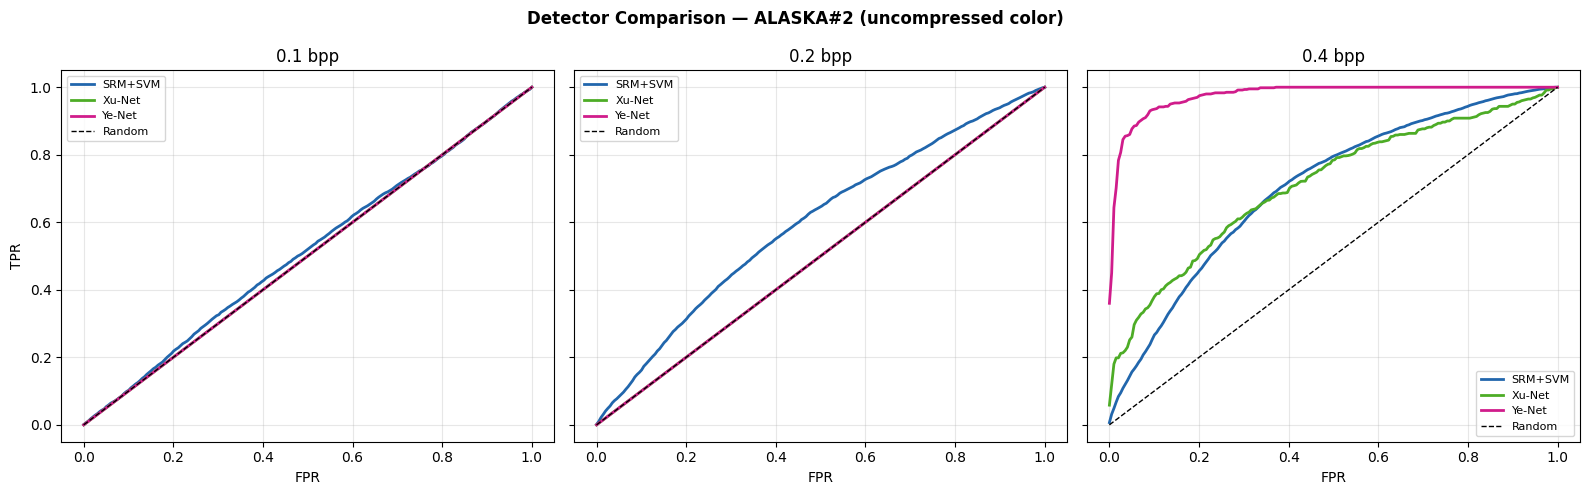

In [31]:
# ═══════════════════════════════════════════════════════════════════════════
# Unified Detector Comparison (SRM+SVM vs. SRNet) — updated
# ═══════════════════════════════════════════════════════════════════════════

rows = []
for bpp in CFG["payload_rates"]:
    rows.append([bpp, "SRM + LinearSVC",
                 f"{svm_aggregated[bpp]['pe_mean']:.4f}±{svm_aggregated[bpp]['pe_std']:.4f}",
                 f"{svm_aggregated[bpp]['auc_mean']:.4f}±{svm_aggregated[bpp]['auc_std']:.4f}"])
    rows.append([bpp, "SRNet",
                 f"{srnet_aggregated[bpp]['pe_mean']:.4f}±{srnet_aggregated[bpp]['pe_std']:.4f}",
                 f"{srnet_aggregated[bpp]['auc_mean']:.4f}±{srnet_aggregated[bpp]['auc_std']:.4f}"])

print(tabulate(rows, headers=["Payload (bpp)", "Detector", "PE", "AUC"], tablefmt="grid"))

fig, axes = plt.subplots(1, len(CFG["payload_rates"]), figsize=(14, 5), sharey=True)
for ax, bpp in zip(axes, CFG["payload_rates"]):
    for name, trials, color in [
        ("SRM+SVM", svm_trial_results[bpp], "#2166ac"),
        ("SRNet",   srnet_results[bpp],      "#d01c8b"),
    ]:
        base_fpr = np.linspace(0, 1, 200)
        tprs = [np.interp(base_fpr, t["fpr"], t["tpr"]) for t in trials]
        ax.plot(base_fpr, np.mean(tprs, axis=0), color=color, linewidth=2, label=name)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
    ax.set_title(f"{bpp} bpp"); ax.set_xlabel("FPR")
    if ax is axes[0]:
        ax.set_ylabel("TPR")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f"Detector Comparison — {CFG['dataset_name']}", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "detector_comparison_roc.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(CFG["output_dir"], "detector_comparison_roc.png"), dpi=200, bbox_inches="tight")
plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# Unified Experimental Settings Table — updated
# ═══════════════════════════════════════════════════════════════════════════

def build_experimental_table_v2() -> pd.DataFrame:
    rows = []
    for bpp in CFG["payload_rates"]:
        n_pairs = len(stego_bank[bpp])
        for name, agg, trials_key in [
            ("SRM + LinearSVC", svm_aggregated[bpp],   "n_trials"),
            ("SRNet",           srnet_aggregated[bpp], "n_trials_dl"),
        ]:
            rows.append({
                "Dataset":              CFG["dataset_name"],
                "Resolution":           CFG["image_res"],
                "Detector":             name,
                "Embedding Rate (bpp)": bpp,
                "Samples (per class)":  n_pairs,
                "Trials":               CFG[trials_key],
                "PE (mean ± std)":      f"{agg['pe_mean']:.4f} ± {agg['pe_std']:.4f}",
                "AUC (mean ± std)":     f"{agg['auc_mean']:.4f} ± {agg['auc_std']:.4f}",
                "PSNR dB":              f"{quality_results[bpp]['psnr_mean']:.2f} ± {quality_results[bpp]['psnr_std']:.2f}",
                "SSIM":                 f"{quality_results[bpp]['ssim_mean']:.6f} ± {quality_results[bpp]['ssim_std']:.6f}",
            })
    return pd.DataFrame(rows)


exp_table = build_experimental_table_v2()
print(tabulate(exp_table, headers="keys", tablefmt="grid", showindex=False))

exp_table.to_csv(os.path.join(CFG["output_dir"], "experimental_table_v2.csv"), index=False)
with open(os.path.join(CFG["output_dir"], "experimental_table_v2.tex"), "w") as f:
    f.write(exp_table.to_latex(index=False, escape=True,
        caption="Detector comparison across embedding rates.", label="tab:detector_comparison"))
print("\nSaved CSV and LaTeX table.")


## Cell 14 — Unified Experimental Settings Table (all detectors)

In [32]:
# def build_experimental_table_v2() -> pd.DataFrame:
#     rows = []
#     for bpp in CFG["payload_rates"]:
#         n_pairs = len(stego_bank[bpp])
#         for name, agg in [
#             ("SRM + LinearSVC", svm_aggregated[bpp]),
#             ("Xu-Net",          xunet_aggregated[bpp]),
#             ("Ye-Net",          yenet_aggregated[bpp]),
#         ]:
#             rows.append({
#                 "Dataset":              CFG["dataset_name"],
#                 "Resolution":           CFG["image_res"],
#                 "Detector":             name,
#                 "Embedding Rate (bpp)": bpp,
#                 "Samples (per class)":  n_pairs,
#                 "Trials":               CFG["n_trials"] if name == "SRM + LinearSVC" else CFG["n_trials_dl"],
#                 "PE (mean ± std)":      f"{agg['pe_mean']:.4f} ± {agg['pe_std']:.4f}",
#                 "AUC (mean ± std)":     f"{agg['auc_mean']:.4f} ± {agg['auc_std']:.4f}",
#                 "PSNR dB":              f"{quality_results[bpp]['psnr_mean']:.2f} ± {quality_results[bpp]['psnr_std']:.2f}",
#                 "SSIM":                 f"{quality_results[bpp]['ssim_mean']:.6f} ± {quality_results[bpp]['ssim_std']:.6f}",
#             })
#     return pd.DataFrame(rows)


# exp_table = build_experimental_table_v2()
# print(tabulate(exp_table, headers="keys", tablefmt="grid", showindex=False))

# exp_table.to_csv(os.path.join(CFG["output_dir"], "experimental_table_v2.csv"), index=False)
# with open(os.path.join(CFG["output_dir"], "experimental_table_v2.tex"), "w") as f:
#     f.write(exp_table.to_latex(index=False, escape=True,
#         caption="Detector comparison across embedding rates.", label="tab:detector_comparison"))
# print("\nSaved CSV and LaTeX table.")


+-------------------------------+--------------+-----------------+------------------------+-----------------------+----------+-------------------+--------------------+--------------+---------------------+
| Dataset                       | Resolution   | Detector        |   Embedding Rate (bpp) |   Samples (per class) |   Trials | PE (mean ± std)   | AUC (mean ± std)   | PSNR dB      | SSIM                |
+===============================+==============+=================+========================+=======================+==========+===================+====================+==============+=====================+
| ALASKA#2 (uncompressed color) | 512×512      | SRM + LinearSVC |                    0.1 |                  1000 |       10 | 0.4886 ± 0.0082   | 0.5118 ± 0.0069    | 58.90 ± 7.92 | 0.999413 ± 0.004560 |
+-------------------------------+--------------+-----------------+------------------------+-----------------------+----------+-------------------+--------------------+-------------

In [ ]:
# 


In [ ]:
# 
